In [15]:
import os
from typing import List, Literal, Optional
from dotenv import load_dotenv, find_dotenv

import tiktoken
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_core.documents import Document
from langchain_core.messages import get_buffer_string, HumanMessage
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnableConfig
from langchain_core.tools import tool
from langchain_nvidia_ai_endpoints import ChatNVIDIA
from langgraph.graph import END, START, MessagesState, StateGraph
from langgraph.prebuilt import ToolNode

In [16]:
_ = load_dotenv(find_dotenv())

In [17]:
import warnings
warnings.filterwarnings('ignore')
import sys
sys.path.append('./vector_store.py')
from vector_store import VectorStoreHelper

filter_vector_opt = [{
        "type": "filter",
        "path": "user_id"
      }]
vector_store_helper = VectorStoreHelper(collection_name="chat_history", search_index_name="chat")
vector_store_helper.clear_data()
vector_store_helper.create_vector_search_index(search_index_name="chat", filter=filter_vector_opt)
vector_store = vector_store_helper.get_vector_store()
recall_vector_store = vector_store

Index 'chat' already exist. Skip create index


In [18]:
import uuid


def get_user_id(config: RunnableConfig) -> str:
    user_id = config["configurable"].get("user_id")
    if user_id is None:
        raise ValueError("User ID needs to be provided to save a memory.")

    return user_id

@tool
def save_recall_memory(memory: str, config: RunnableConfig) -> str:
    """Save memory to vector store for later semantic retrieval."""
    user_id = get_user_id(config)
    document = Document(
        page_content=memory, id=str(uuid.uuid4()), metadata={"user_id": user_id}
    )
    vector_store_helper.add_data([document])
    return memory


@tool
def search_recall_memories(query: str, config: RunnableConfig) -> str:
    """Search for relevant memories"""
    user_id = get_user_id(config)
    filter = {"user_id": {"$eq": user_id}}
    search_kwargs = {
        "k": 3,
        "fetch_k": 5,
        "pre_filter": filter
    }

    documents = recall_vector_store.as_retriever(search_type="mmr",
                                                 search_kwargs=search_kwargs).invoke(query)

    for doc in documents:
        print(f"* {doc.page_content} [{doc.metadata}]")

    return "\n".join(document.page_content for document in documents)

In [19]:
search = TavilySearchResults(max_results=1)
tools = [save_recall_memory, search_recall_memories, search]

In [20]:
class State(MessagesState):
    # add memories that will be retrieved based on the conversation context
    recall_memories: List[str]

In [21]:
# Define the prompt template for the agent
prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a helpful assistant with advanced long-term memory"
            " capabilities. Powered by a stateless LLM, you must rely on"
            " external memory to store information between conversations."
            " Utilize the available memory tools to store and retrieve"
            " important details that will help you better attend to the user's"
            " needs and understand their context.\n\n"
            "Memory Usage Guidelines:\n"
            "1. Actively use memory tools (save_recall_memory, search_recall_memories)"
            " to build a comprehensive understanding of the user.\n"
            "2. Make informed suppositions and extrapolations based on stored"
            " memories.\n"
            "3. Regularly reflect on past interactions to identify patterns and"
            " preferences.\n"
            "4. Update your mental model of the user with each new piece of"
            " information.\n"
            "5. Cross-reference new information with existing memories for"
            " consistency.\n"
            "6. Prioritize storing emotional context and personal values"
            " alongside facts.\n"
            "7. Use memory to anticipate needs and tailor responses to the"
            " user's style.\n"
            "8. Recognize and acknowledge changes in the user's situation or"
            " perspectives over time.\n"
            "9. Leverage memories to provide personalized examples and"
            " analogies.\n"
            "10. Recall past challenges or successes to inform current"
            " problem-solving.\n\n"
            "## Recall Memories\n"
            "Recall memories are contextually retrieved based on the current"
            " conversation:\n{recall_memories}\n\n"
            "## Instructions\n"
            "Engage with the user naturally, as a trusted colleague or friend."
            " There's no need to explicitly mention your memory capabilities."
            " Instead, seamlessly incorporate your understanding of the user"
            " into your responses. Be attentive to subtle cues and underlying"
            " emotions. Adapt your communication style to match the user's"
            " preferences and current emotional state. Use tools to persist"
            " information you want to retain in the next conversation. If you"
            " do call tools, all text preceding the tool call is an internal"
            " message. Respond AFTER calling the tool, once you have"
            " confirmation that the tool completed successfully. \n\n",
        ),
        ("placeholder", "{messages}"),
    ]
)

In [22]:
from langchain_mongodb.chat_message_histories import MongoDBChatMessageHistory

def get_session_history(user_id: str, thread_id: str):
    return MongoDBChatMessageHistory(connection_string=os.environ.get("MONGODB_ATLAS_CLUSTER_URI"), database_name="langchain_test_db", collection_name="chat_history", session_id=thread_id, session_id_key="session_id", history_key="history")

In [23]:
from langchain_core.runnables.history import RunnableWithMessageHistory
from langchain_core.runnables import ConfigurableFieldSpec
from langchain_core.messages import RemoveMessage

msg = get_session_history("1", "chat_thread_1").messages
model = chat_model = ChatNVIDIA(
    model="meta/llama-3.1-70b-instruct",
    max_tokens=2048,
    api_key=os.environ["NVIDIA_API_KEY"],
    temperature=0.0,
)

model_with_tools = model.bind_tools(tools=tools)
bound = prompt | model_with_tools
chain_history = RunnableWithMessageHistory(bound, get_session_history, input_messages_key="messages", history_messages_key="histories", history_factory_config=[
    ConfigurableFieldSpec(
        id="user_id",
        annotation=str,
        name="User ID",
        description="Unique identifier for the user.",
        default="",
        is_shared=True,
    ),
    ConfigurableFieldSpec(
        id="thread_id",
        annotation=str,
        name="Thread ID",
        description="Unique identifier for the conversation.",
        default="",
        is_shared=True,
    ),
])


tokenizer = tiktoken.encoding_for_model("gpt-4o")


def agent(state: State) -> State:
    """Process the current state and generate a response using the LLM.

    Args:
        state (schemas.State): The current state of the conversation.

    Returns:
        schemas.State: The updated state with the agent's response.
    """
    memories = state.get("recall_memories") or ""
    recall_str = (
        "<recall_memory>\n" + memories + "\n</recall_memory>"
    )
    prediction = bound.invoke(
        {
            "messages": state["messages"],
            "recall_memories": recall_str,
        }
    )
    return {
        "messages": [prediction],
    }


def load_memories(state: State, config: RunnableConfig) -> State:
    """Load memories for the current conversation.

    Args:
        state (schemas.State): The current state of the conversation.
        config (RunnableConfig): The runtime configuration for the agent.

    Returns:
        State: The updated state with loaded memories.
    """
    convo_str = get_buffer_string(state["messages"])
    convo_str = tokenizer.decode(tokenizer.encode(convo_str)[:2048])
    recall_memories = search_recall_memories.invoke(convo_str, config)

    return {
        "recall_memories": recall_memories,
    }


def delete_messages(state: State) -> State:
    messages = state["messages"]
    if len(messages) > 12:
        return {"messages": [RemoveMessage(msg.id) for msg in messages[:-12]]}

    return {"messages": messages}


# type: ignore
def route_tools(state: State) -> Literal["tools", "delete_messages"]:
    """Determine whether to use tools or end the conversation based on the last message.

    Args:
        state (schemas.State): The current state of the conversation.

    Returns:
        Literal["tools", "delete_messages"]: The next step in the graph.
    """

    msg = state["messages"][-1]
    if msg.tool_calls:
        return "tools"

    return "delete_messages"

In [24]:
def pretty_print_stream_chunk(chunk):
    for node, updates in chunk.items():
        if "messages" in updates:
            updates["messages"][-1].pretty_print()

        print("\n")

In [25]:
# Create the graph and add nodes


builder = StateGraph(State)
builder.add_node(load_memories)
builder.add_node(delete_messages)
builder.add_node(agent)
builder.add_node("tools", ToolNode(tools))

# Add edges to the graph
builder.add_edge(START, "load_memories")
builder.add_edge("load_memories", "agent")
builder.add_conditional_edges("agent", route_tools, ["tools", "delete_messages"])
builder.add_edge("tools", "agent")
builder.add_edge("delete_messages", END)


In [26]:
# Compile the graph
from memory_saver import MongoDBSaver
import sys
sys.path.append("../..")

with MongoDBSaver.from_conn_info(host=os.environ.get("MONGODB_ATLAS_CLUSTER_URI"), db_name="langchain_test_db") as checkpoint:
    graph = builder.compile(checkpointer=checkpoint)
    config = {"configurable": {"user_id": "1", "thread_id": "chat_thread_1"}}
    while True:
        query = input("Enter messages: ")
        if query == 'stop':
            break
        for chunk in graph.stream({"messages": [HumanMessage(query)]}, config=config):
            pretty_print_stream_chunk(chunk)

    messages = graph.get_state(config).values["messages"]
    print(messages)



================================== Ai Message ==================================

Once upon a time, in a land far, far away, there was a magical realm called Aethoria. Aethoria was a place of breathtaking beauty, where the skies were perpetually painted with hues of crimson and gold, and the air was sweet with the scent of enchanted blooms.

In the heart of Aethoria lay the mystical forest of Elvendom, where ancient trees whispered secrets to the wind, and the creatures of the wild roamed free. It was here that our tale begins, with a young apprentice named Eira Shadowglow.

Eira was a skilled huntress, with hair as black as the night sky and eyes that shone like the stars. She lived in the village of Brindlemark, on the outskirts of Elvendom, where she was trained by the wise and powerful wizard, Thorne Silvermist.

One day, while out on a hunt, Eira stumbled upon a hidden glade deep within the forest. In the center of the clearing stood an enormous tree, its trunk twisted and gnarl

Exception: [400] Bad Request
Input length 828 exceeds maximum allowed token size 512

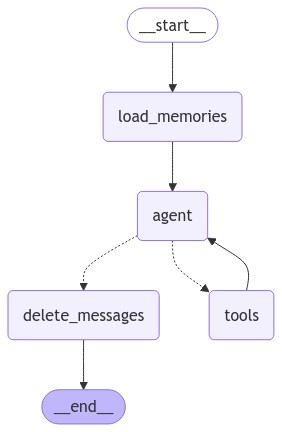

In [ ]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
# from langchain_core.messages import AIMessage, filter_messages

# msg = get_session_history("1", "chat_thread_1").messages
# for m in filter_messages(messages=msg, include_types=[HumanMessage, AIMessage]):
#     if isinstance(m, AIMessage) and m.tool_calls:
#       continue
#     m.pretty_print()